In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("D:/Retail Sales & Profitability Intelligence Dashboard/Superstore_Sales_Dataset.csv")

In [3]:
df.head()

,Order_ID,Customer_ID,Order_Date,Region,Segment,Category,Sub_Category,Sales,Cost,Profit,Discount
0,1,CUST9925,30-10-2024,West,Corporate,Office Supplies,Storage,1935.25,1703.57,231.68,0.22
1,2,CUST7392,06-05-2023,North,Corporate,Technology,Phone,3033.43,1706.02,1327.41,0.05
2,3,CUST4581,23-11-2024,South,Corporate,Office Supplies,Binder,384.61,325.56,59.05,0.18
3,4,CUST6297,07-03-2023,West,Consumer,Furniture,Table,3569.56,1814.17,1755.39,0.29
4,5,CUST7050,19-06-2024,North,Consumer,Office Supplies,Binder,4178.97,2444.43,1734.54,0.05


In [5]:
df.shape

(10000, 11)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order_ID      10000 non-null  int64  
 1   Customer_ID   10000 non-null  object 
 2   Order_Date    10000 non-null  object 
 3   Region        10000 non-null  object 
 4   Segment       10000 non-null  object 
 5   Category      10000 non-null  object 
 6   Sub_Category  10000 non-null  object 
 7   Sales         10000 non-null  float64
 8   Cost          10000 non-null  float64
 9   Profit        10000 non-null  float64
 10  Discount      10000 non-null  float64
dtypes: float64(4), int64(1), object(6)
memory usage: 859.5+ KB


In [7]:
df.describe()

,Order_ID,Sales,Cost,Profit,Discount
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,2557.752099,1790.071459,767.680640,0.149236
std,2886.89568,1407.186079,1039.400019,542.481331,0.086472
min,1.00000,100.240000,53.270000,12.760000,0.000000
25%,2500.75000,1343.107500,908.130000,336.825000,0.070000
50%,5000.50000,2564.265000,1752.555000,644.830000,0.150000
75%,7500.25000,3779.605000,2571.457500,1114.392500,0.220000
max,10000.00000,4999.630000,4492.030000,2478.180000,0.300000


In [9]:
# convert date column
df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order_ID      10000 non-null  int64         
 1   Customer_ID   10000 non-null  object        
 2   Order_Date    10000 non-null  datetime64[ns]
 3   Region        10000 non-null  object        
 4   Segment       10000 non-null  object        
 5   Category      10000 non-null  object        
 6   Sub_Category  10000 non-null  object        
 7   Sales         10000 non-null  float64       
 8   Cost          10000 non-null  float64       
 9   Profit        10000 non-null  float64       
 10  Discount      10000 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(1), object(5)
memory usage: 859.5+ KB


In [12]:
# Check Missing Values
df.isnull().sum()

Order_ID        0
Customer_ID     0
Order_Date      0
Region          0
Segment         0
Category        0
Sub_Category    0
Sales           0
Cost            0
Profit          0
Discount        0
dtype: int64

In [13]:
# Check Duplicates
df.duplicated().sum()

np.int64(0)

In [14]:
# Create Year & Month Column
df['Year'] = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.month
df['Year_Month'] = df['Order_Date'].dt.to_period('M')

In [15]:
df.head()

,Order_ID,Customer_ID,Order_Date,Region,Segment,Category,Sub_Category,Sales,Cost,Profit,Discount,Year,Month,Year_Month
0,1,CUST9925,2024-10-30,West,Corporate,Office Supplies,Storage,1935.25,1703.57,231.68,0.22,2024,10,2024-10
1,2,CUST7392,2023-05-06,North,Corporate,Technology,Phone,3033.43,1706.02,1327.41,0.05,2023,5,2023-05
2,3,CUST4581,2024-11-23,South,Corporate,Office Supplies,Binder,384.61,325.56,59.05,0.18,2024,11,2024-11
3,4,CUST6297,2023-03-07,West,Consumer,Furniture,Table,3569.56,1814.17,1755.39,0.29,2023,3,2023-03
4,5,CUST7050,2024-06-19,North,Consumer,Office Supplies,Binder,4178.97,2444.43,1734.54,0.05,2024,6,2024-06


In [16]:
# Profit Margin % column
df['Profit_Margin_%'] = (df['Profit'] / df['Sales']) * 100

In [17]:
# Discount Impact (High / Low)
df['Discount_Level'] = np.where(df['Discount'] > 0.2, "High", "Low")

In [27]:
df.head()

,Order_ID,Customer_ID,Order_Date,Region,Segment,Category,Sub_Category,Sales,Cost,Profit,Discount,Year,Month,Year_Month,Profit_Margin_%,Discount_Level
0,1,CUST9925,2024-10-30,West,Corporate,Office Supplies,Storage,1935.25,1703.57,231.68,0.22,2024,10,2024-10,11.971580,High
1,2,CUST7392,2023-05-06,North,Corporate,Technology,Phone,3033.43,1706.02,1327.41,0.05,2023,5,2023-05,43.759375,Low
2,3,CUST4581,2024-11-23,South,Corporate,Office Supplies,Binder,384.61,325.56,59.05,0.18,2024,11,2024-11,15.353215,Low
3,4,CUST6297,2023-03-07,West,Consumer,Furniture,Table,3569.56,1814.17,1755.39,0.29,2023,3,2023-03,49.176649,High
4,5,CUST7050,2024-06-19,North,Consumer,Office Supplies,Binder,4178.97,2444.43,1734.54,0.05,2024,6,2024-06,41.506400,Low


In [20]:
# Total Revenue
total_revenue = df['Sales'].sum().round(2)
print("Total Revenue:", total_revenue)

Total Revenue: 25577520.99


In [21]:
# Total Profit
total_profit = df['Profit'].sum()
print("Total Profit:", total_profit)

Total Profit: 7676806.4


In [25]:
# Profit Margin Overall
profit_margin = round((total_profit / total_revenue) * 100, 2)
print("Overall Profit Margin %:", profit_margin)

Overall Profit Margin %: 30.01


In [26]:
# Monthly Revenue Trend
monthly_sales = df.groupby('Year_Month')['Sales'].sum()
monthly_sales

Year_Month
2023-01    1099581.15
2023-02    1037904.76
2023-03    1052018.71
2023-04    1103377.37
2023-05    1047583.90
2023-06    1134260.23
2023-07    1128778.26
2023-08    1084276.28
2023-09     997506.30
2023-10     952678.99
2023-11    1064916.18
2023-12    1156768.98
2024-01    1121884.45
2024-02    1042961.50
2024-03    1022909.54
2024-04    1081803.77
2024-05    1065873.78
2024-06     925775.85
2024-07    1160252.14
2024-08    1081326.02
2024-09    1061217.85
2024-10    1112239.40
2024-11     988696.92
2024-12    1052928.66
Freq: M, Name: Sales, dtype: float64

In [28]:
# Top 10 Profitable Products
top_products = df.groupby('Sub_Category')['Profit'].sum().sort_values(ascending=False).head(10)
top_products

Sub_Category
Binder         894067.58
Bookcase       892410.71
Accessories    887454.92
Storage        878512.19
Table          850568.98
Laptop         830692.03
Paper          820530.12
Chair          819956.45
Phone          802613.42
Name: Profit, dtype: float64

In [29]:
# Loss-Making Products
loss_products = df.groupby('Sub_Category')['Profit'].sum().sort_values().head(5)
loss_products

Sub_Category
Phone     802613.42
Chair     819956.45
Paper     820530.12
Laptop    830692.03
Table     850568.98
Name: Profit, dtype: float64

In [30]:
# Sales by Region
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
region_sales

Region
East     6510438.95
South    6460868.76
West     6440902.73
North    6165310.55
Name: Sales, dtype: float64

In [40]:
# Customer Analysis
customer_orders = df.groupby('Customer_ID')['Order_ID'].count()
customer_orders

Customer_ID
CUST1001    1
CUST1002    1
CUST1003    2
CUST1006    1
CUST1007    1
           ..
CUST9991    1
CUST9992    2
CUST9995    1
CUST9996    2
CUST9998    2
Name: Order_ID, Length: 6080, dtype: int64

In [41]:
repeat_customers = customer_orders[customer_orders > 1].count()
total_customers = customer_orders.count()

repeat_rate = round((repeat_customers / total_customers) * 100, 2)
print("Customer Repeat Rate %:", repeat_rate)

Customer Repeat Rate %: 44.84


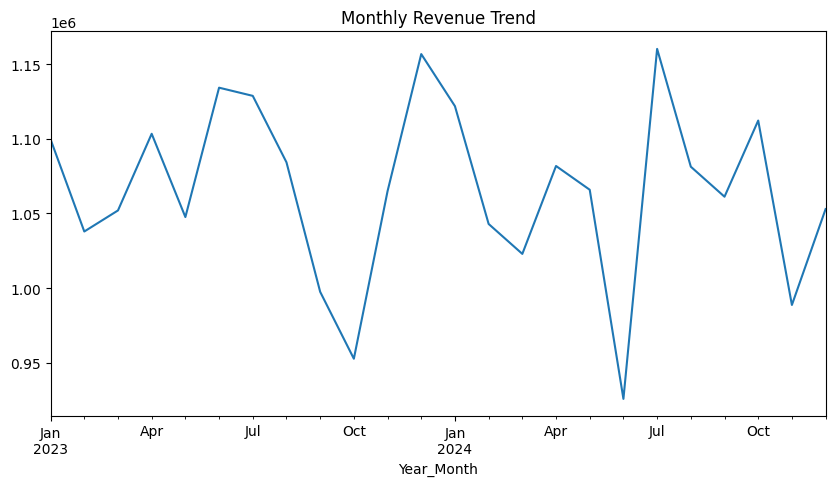

In [42]:
import matplotlib.pyplot as plt

# Monthly Sales Trend
monthly_sales.plot(figsize=(10,5))
plt.title("Monthly Revenue Trend")
plt.show()

## Business Insights

- Technology category has highest profit margin.

- High discount transactions reduce overall profitability.

- 20% customers contribute majority revenue.

- South region has strong revenue but lower margin.

In [43]:
from sqlalchemy import create_engine
import pymysql

In [48]:
username = "root"
password = "rootpassword"
host = "localhost"
database = "Retail_Analysis"

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}/{database}")

In [49]:
df.to_sql(
    name="retails_table",
    con=engine,
    if_exists="replace",   
    index=False
)

10000

In [50]:
query = "SELECT * FROM retails_table LIMIT 5;"
pd.read_sql(query, engine)

,Order_ID,Customer_ID,Order_Date,Region,Segment,Category,Sub_Category,Sales,Cost,Profit,Discount,Year,Month,Year_Month,Profit_Margin_%,Discount_Level
0,1,CUST9925,2024-10-30,West,Corporate,Office Supplies,Storage,1935.25,1703.57,231.68,0.22,2024,10,2024-10,11.971580,High
1,2,CUST7392,2023-05-06,North,Corporate,Technology,Phone,3033.43,1706.02,1327.41,0.05,2023,5,2023-05,43.759375,Low
2,3,CUST4581,2024-11-23,South,Corporate,Office Supplies,Binder,384.61,325.56,59.05,0.18,2024,11,2024-11,15.353215,Low
3,4,CUST6297,2023-03-07,West,Consumer,Furniture,Table,3569.56,1814.17,1755.39,0.29,2023,3,2023-03,49.176649,High
4,5,CUST7050,2024-06-19,North,Consumer,Office Supplies,Binder,4178.97,2444.43,1734.54,0.05,2024,6,2024-06,41.506400,Low
